Dataset Loaded Successfully

First 5 Records
   warehouse_inventory_level  handling_equipment_availability  \
0                 985.716862                         0.481294   
1                 985.716862                         0.481294   
2                 985.716862                         0.481294   
3                 396.700206                         0.620780   
4                 396.700206                         0.620780   

   order_fulfillment_status  weather_condition_severity  shipping_costs  \
0                  0.761166                    0.359066      456.503853   
1                  0.761166                    0.359066      456.503853   
2                  0.761166                    0.359066      456.503853   
3                  0.196594                    0.230660      640.408205   
4                  0.196594                    0.230660      640.408205   

   supplier_reliability_score  lead_time_days  historical_demand  \
0                    0.986064        2.128009

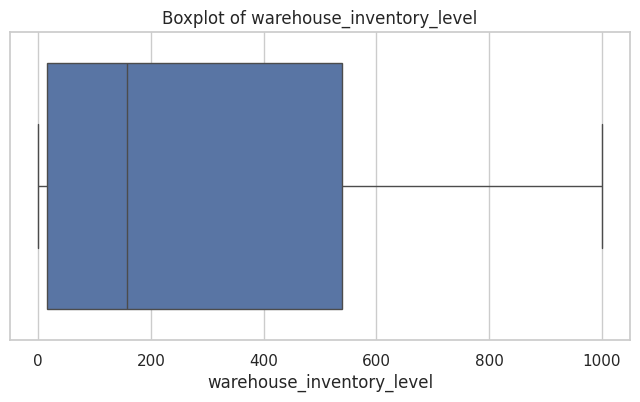

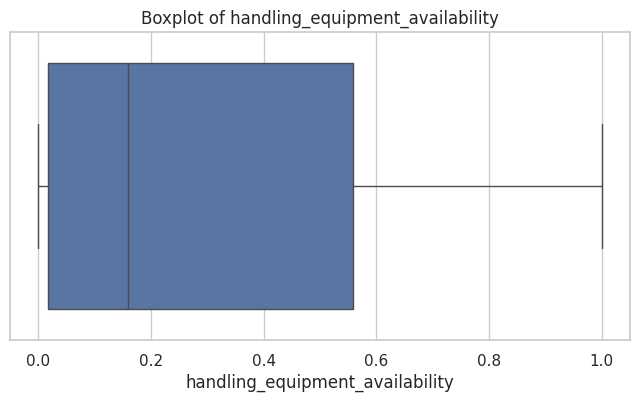

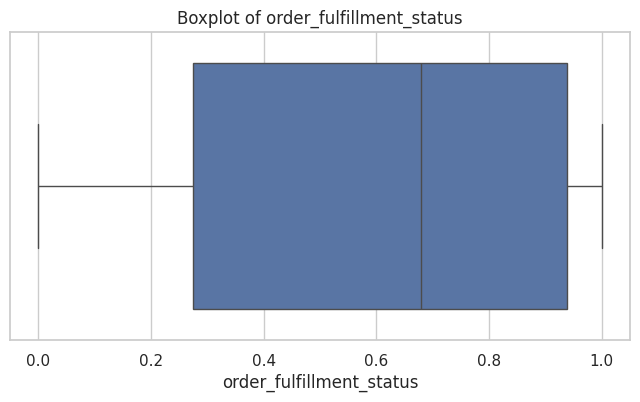

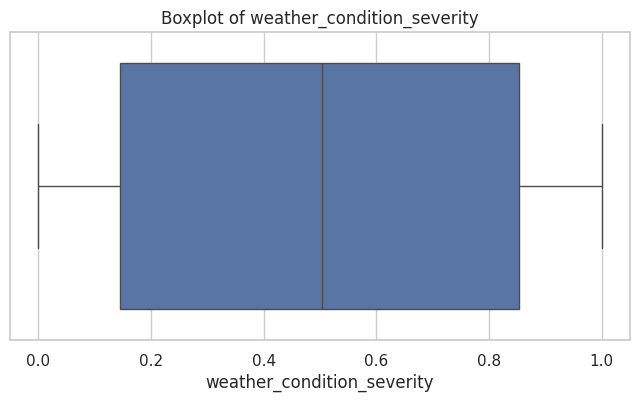

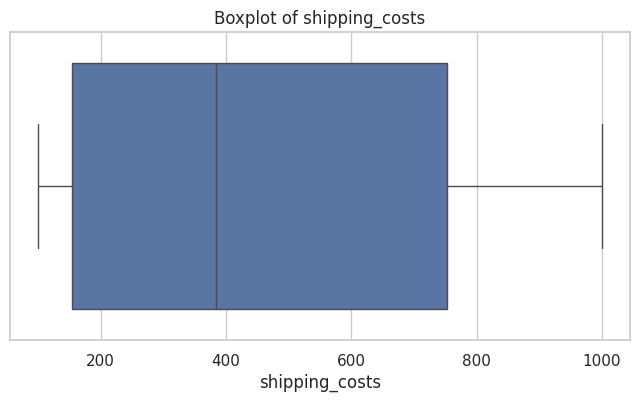

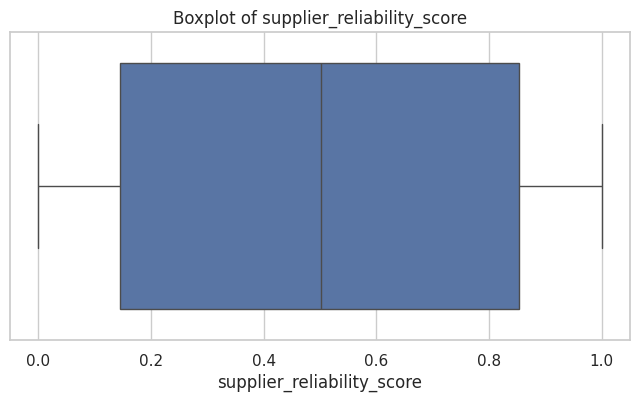

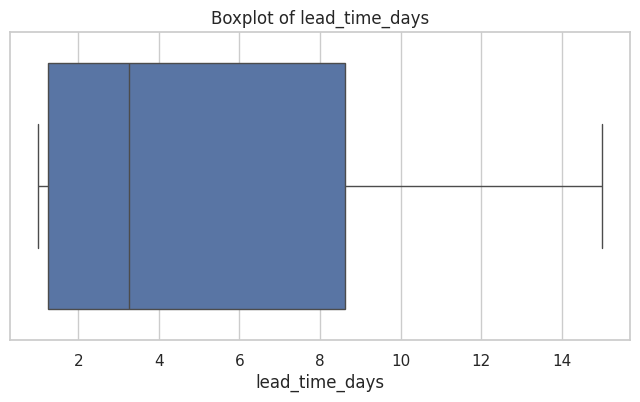

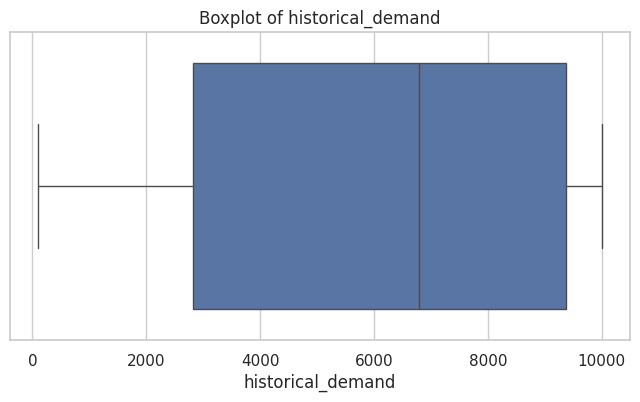

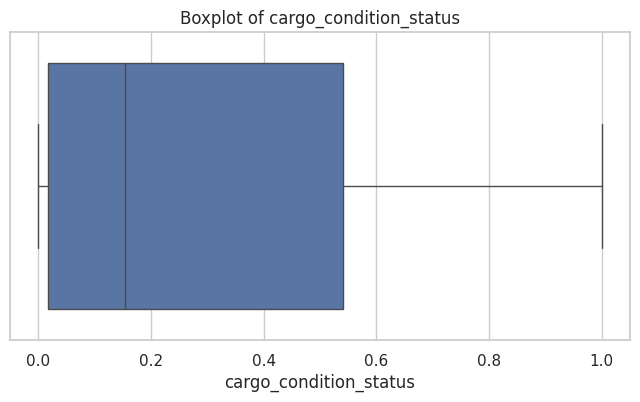

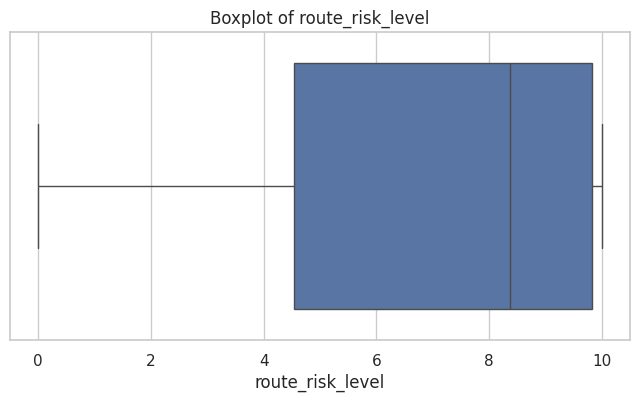

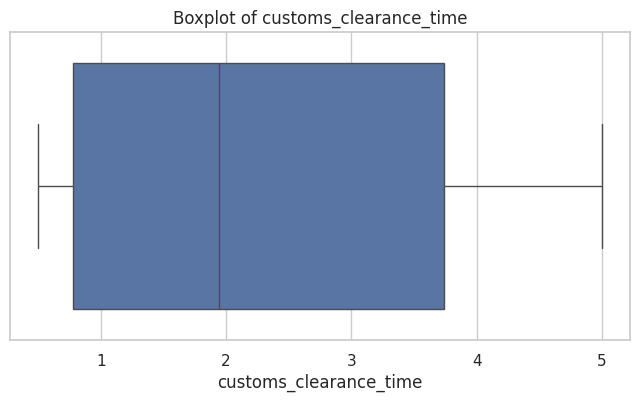

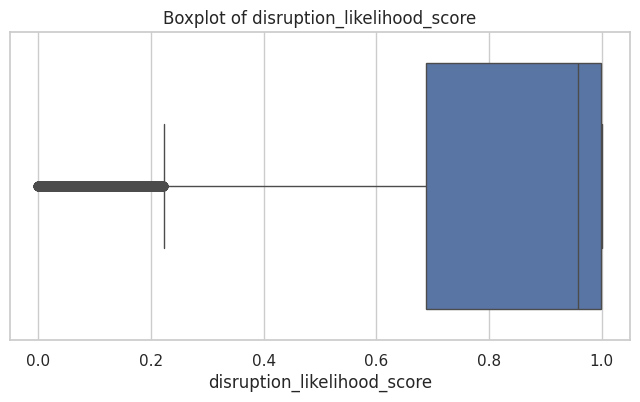

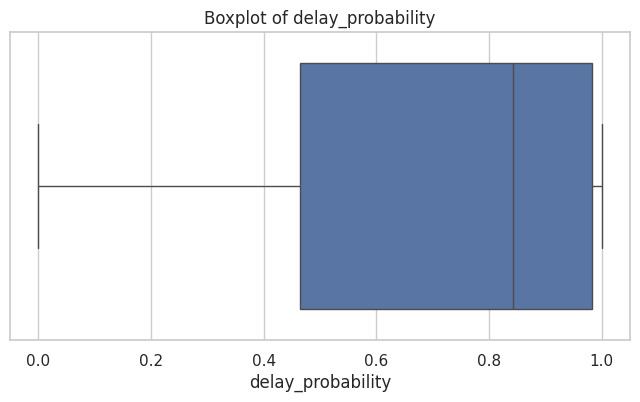

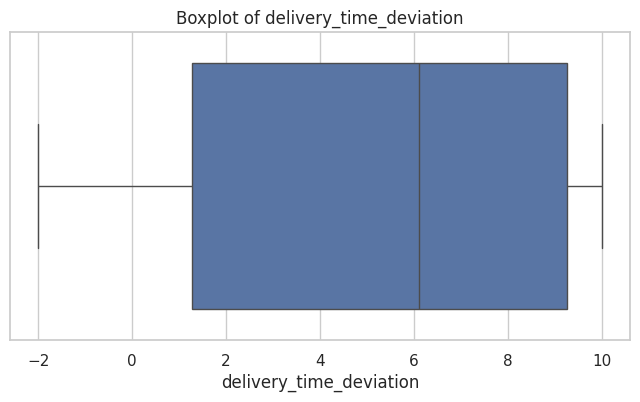

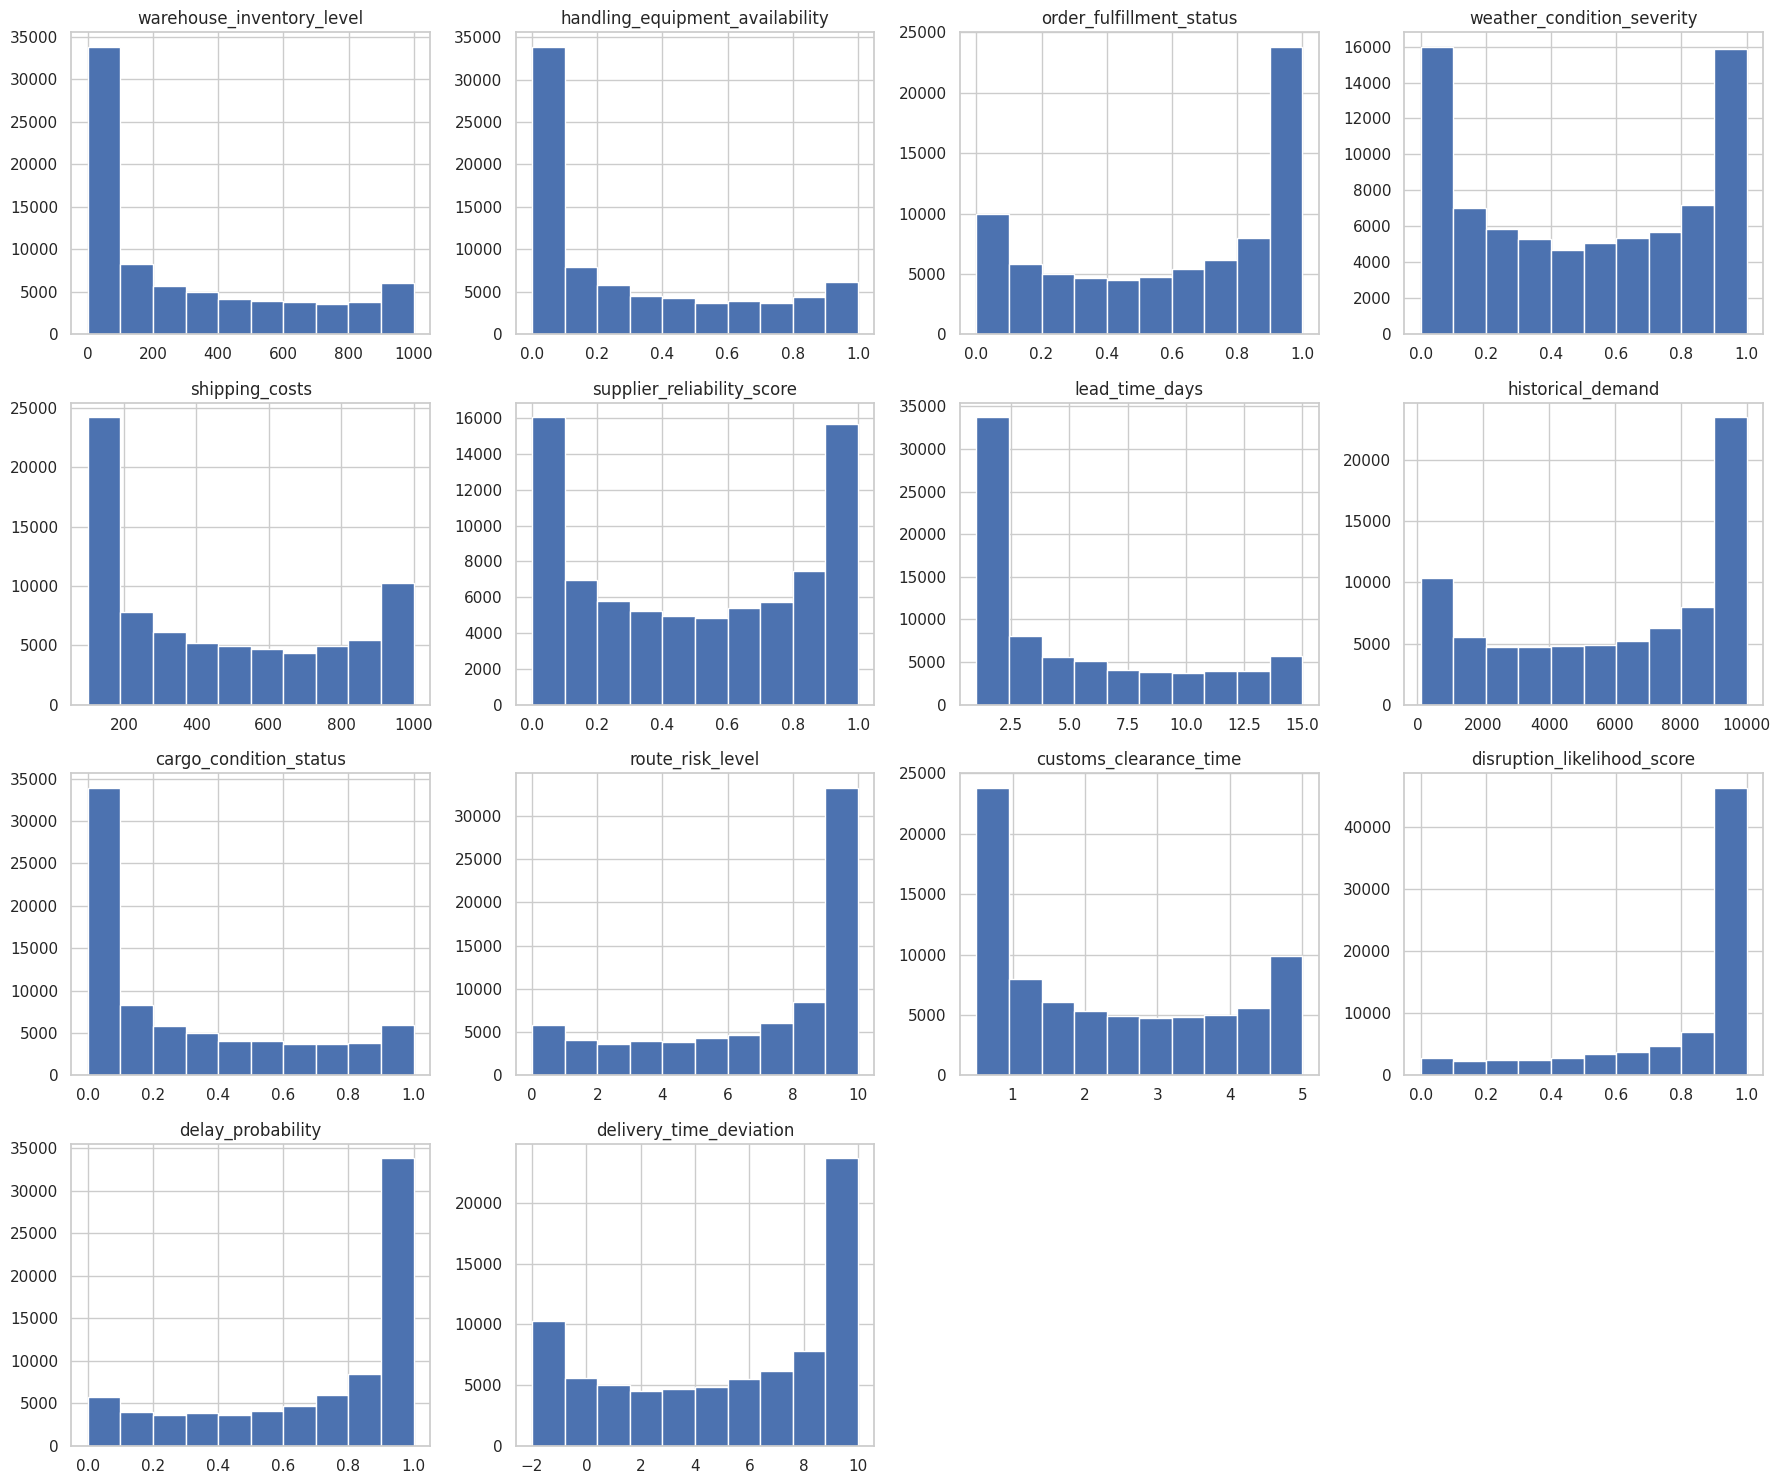

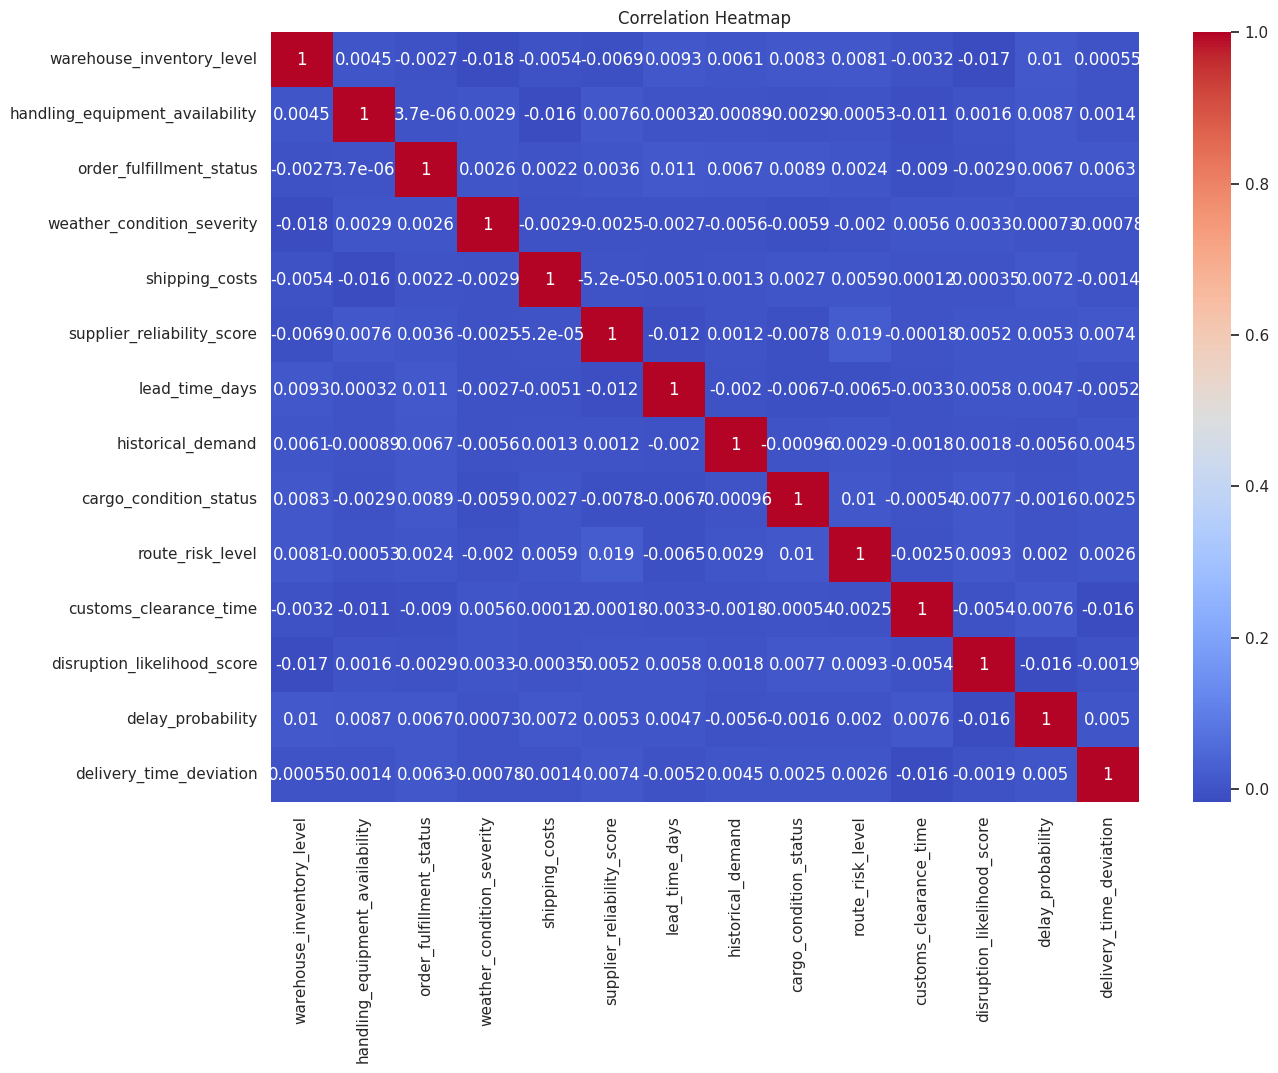


Normalized Data
   warehouse_inventory_level  handling_equipment_availability  \
0                   0.985720                         0.481294   
1                   0.985720                         0.481294   
2                   0.985720                         0.481294   
3                   0.396701                         0.620781   
4                   0.396701                         0.620781   

   order_fulfillment_status  weather_condition_severity  shipping_costs  \
0                  0.761166                    0.359066        0.396115   
1                  0.761166                    0.359066        0.396115   
2                  0.761166                    0.359066        0.396115   
3                  0.196593                    0.230660        0.600454   
4                  0.196593                    0.230660        0.600454   

   supplier_reliability_score  lead_time_days  historical_demand  \
0                    0.986064        0.080572           0.000078   
1    

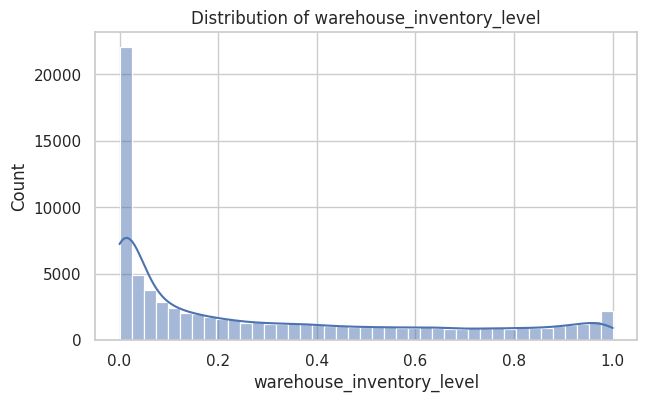

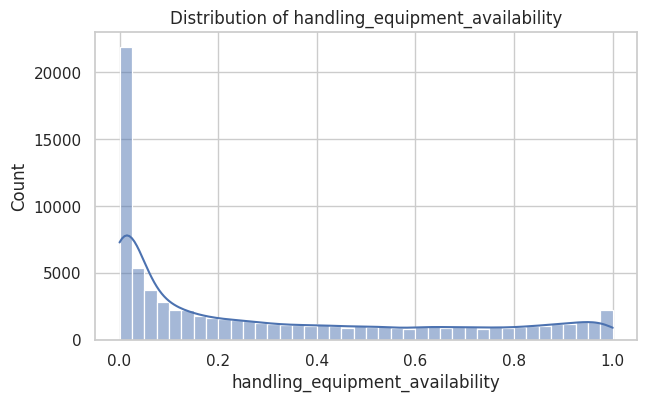

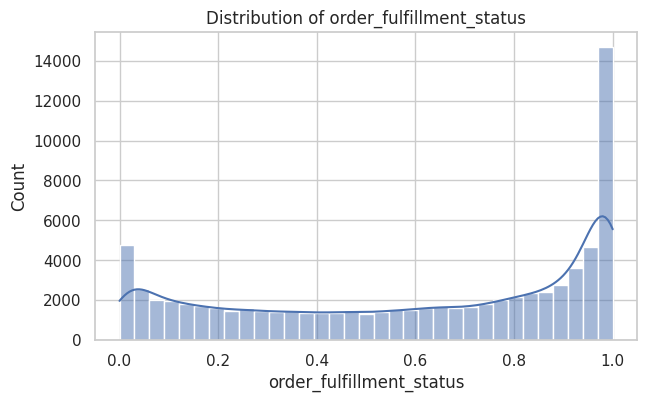

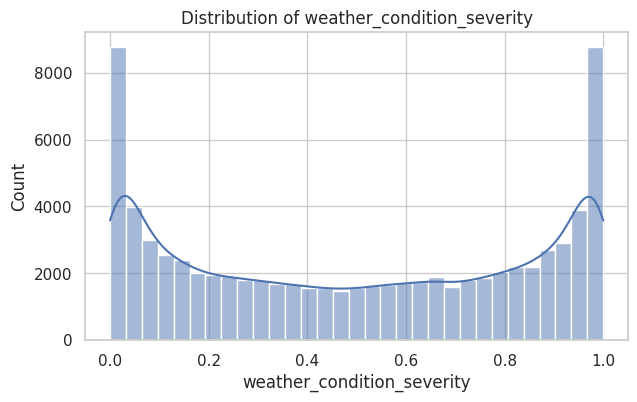

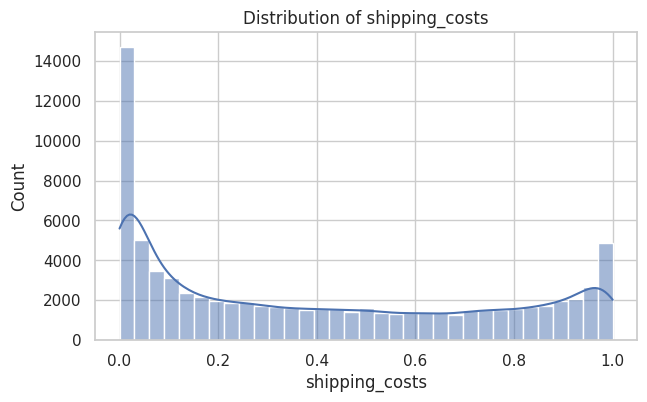

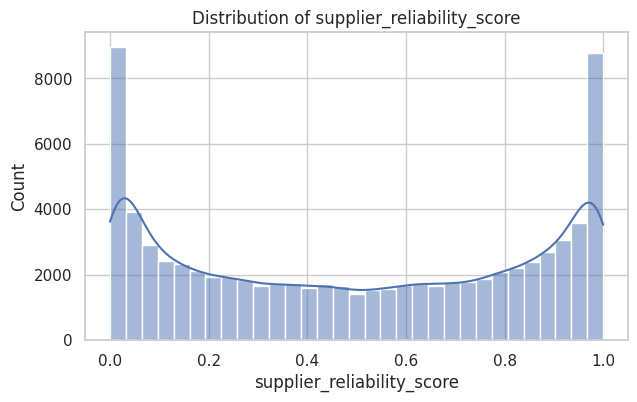

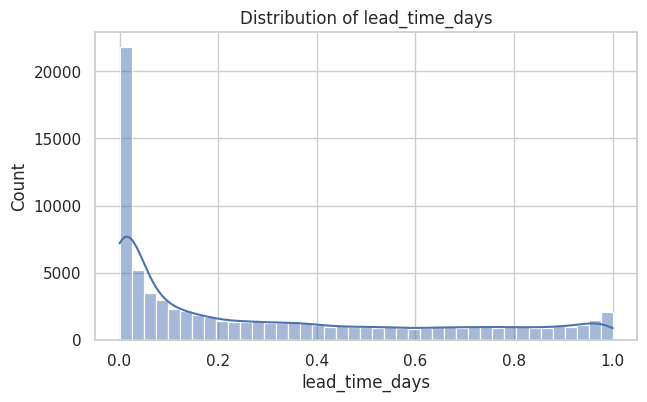

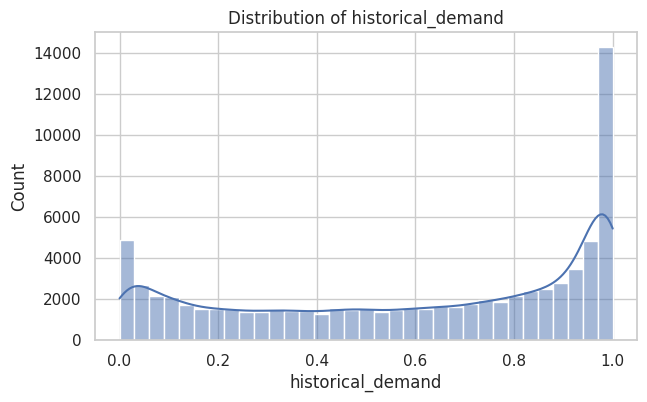

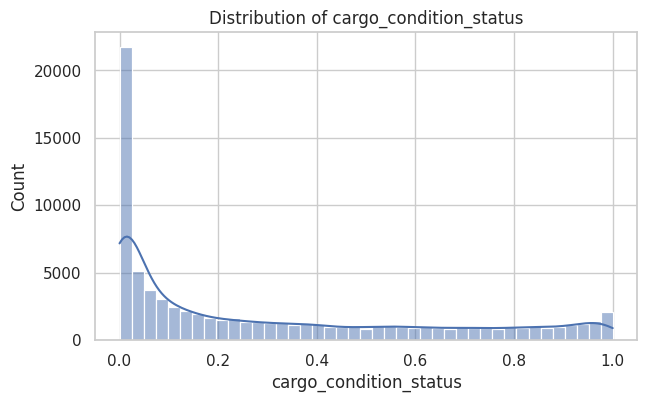

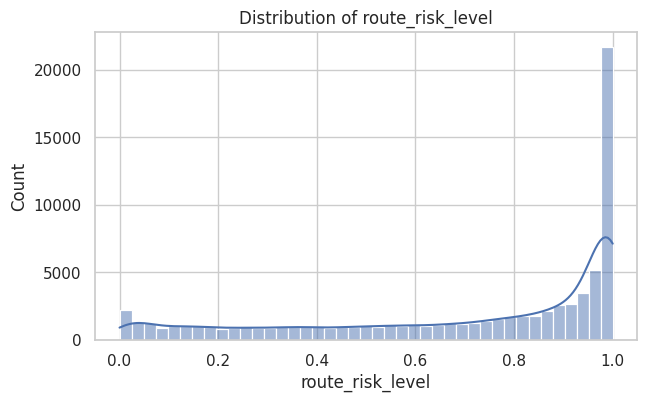

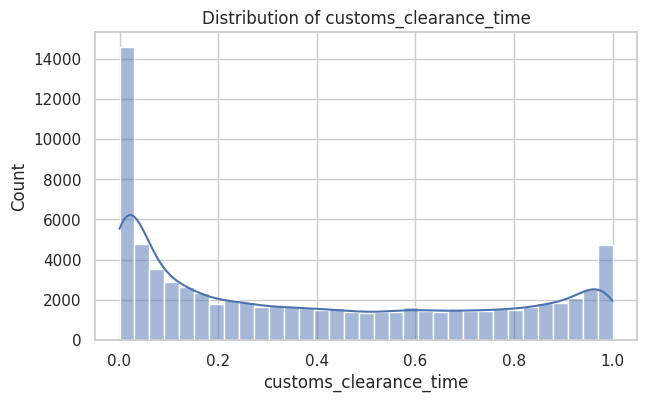

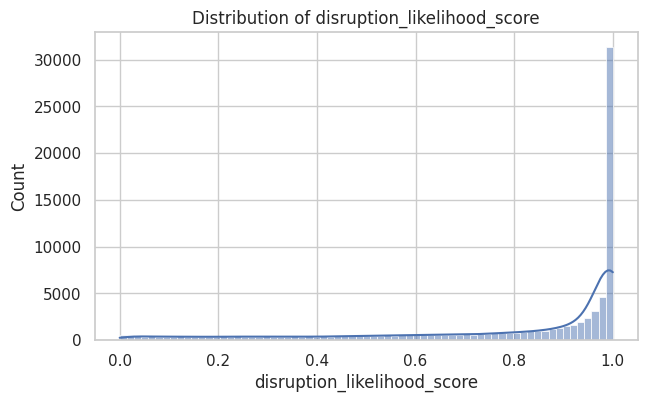

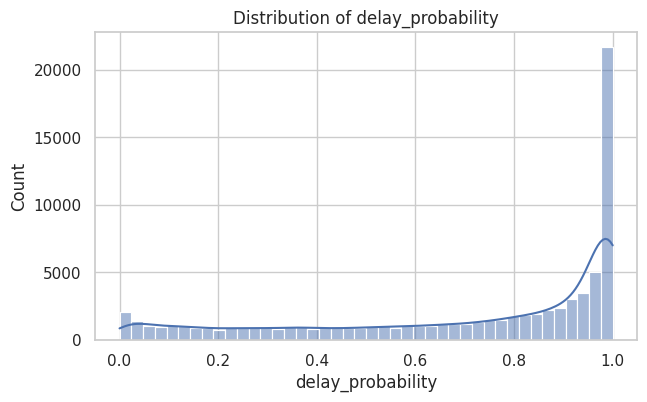

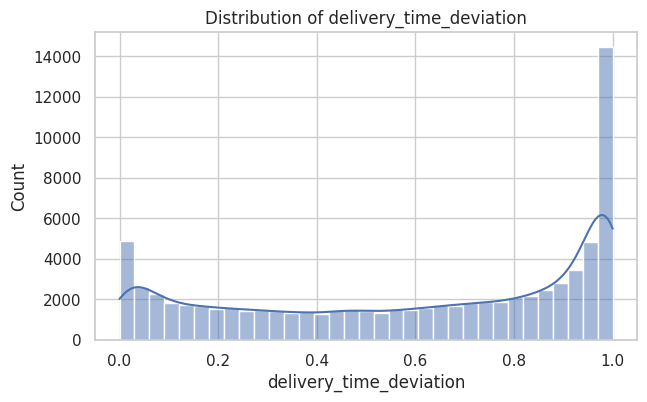

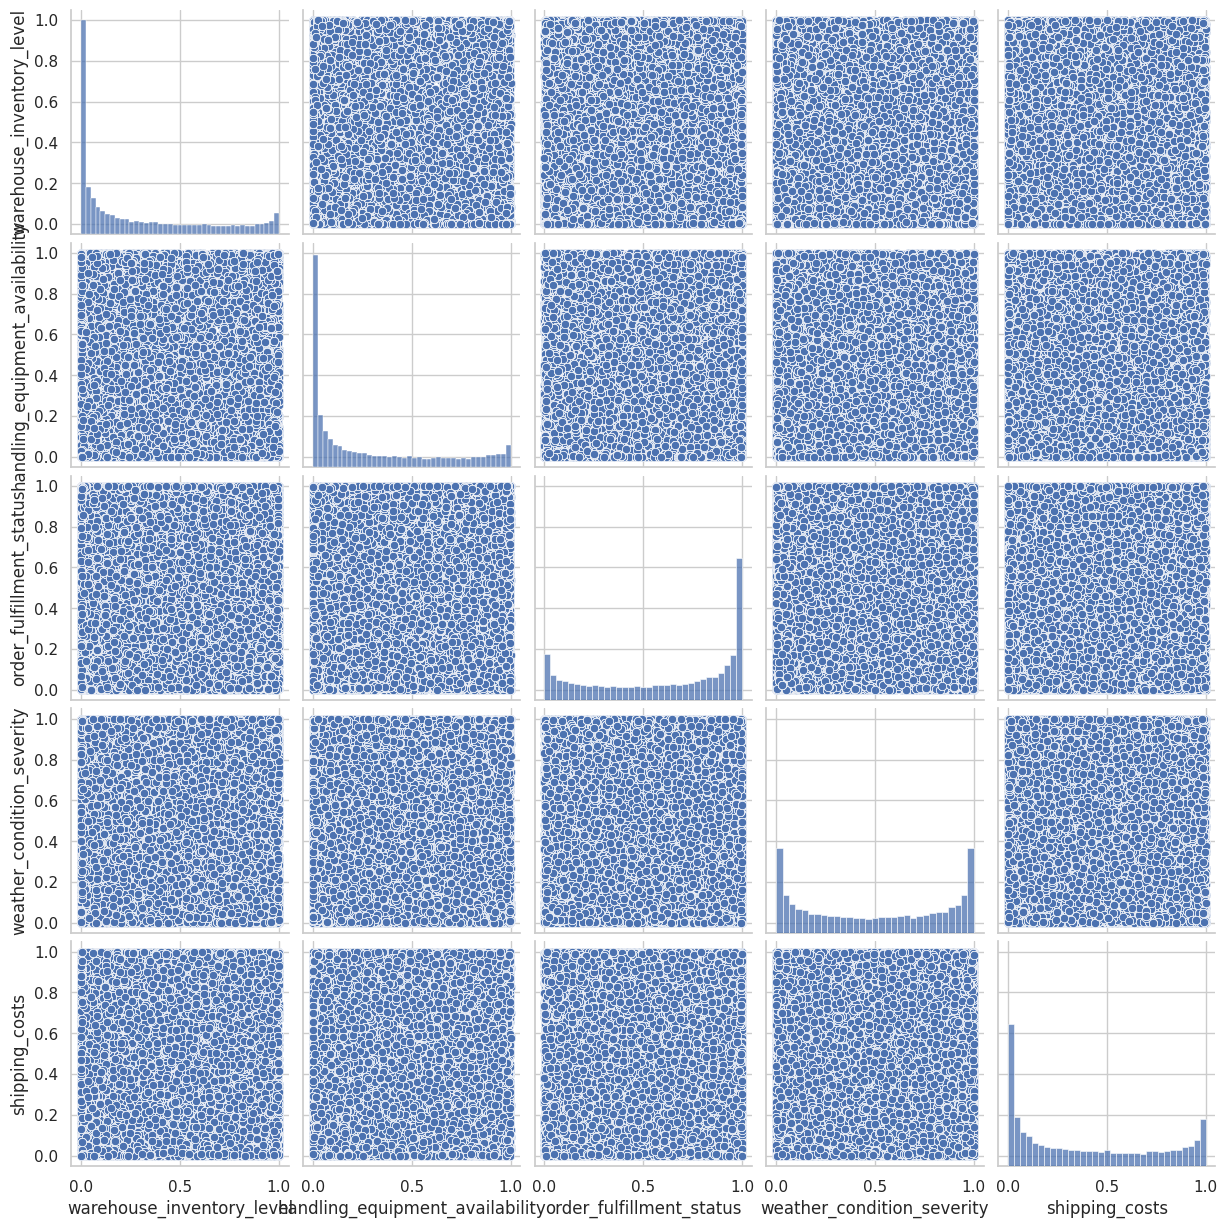


Cleaned Dataset Saved Successfully

EDA COMPLETED SUCCESSFULLY
Final Dataset Shape : (78047, 18)
Missing Values : 0
Duplicate Rows : 0
Numerical Columns : 14
Categorical Columns : 4


In [7]:

# EXPERIMENT 3
# EXPLORATORY DATA ANALYSIS (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")


df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")

print("Dataset Loaded Successfully")

# -----------------------------
# STEP 4 : Display Dataset
# -----------------------------

print("\nFirst 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

# -----------------------------
# STEP 5 : Dataset Information
# -----------------------------

print("\nDataset Information")
print(df.info())

print("\nData Types")
print(df.dtypes)

# -----------------------------
# STEP 6 : Summary Statistics
# -----------------------------

print("\nSummary Statistics")
print(df.describe(include='all'))

# ============================================================
# PROGRAM 1
# IDENTIFY MISSING VALUES
# ============================================================

print("\nMissing Values")

print(df.isnull())

# ============================================================
# PROGRAM 2
# COUNT MISSING VALUES
# ============================================================

print("\nCount Missing Values")

print(df.isnull().sum())

# ============================================================
# PROGRAM 3
# HANDLE MISSING VALUES
# ============================================================

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Filling")

print(df.isnull().sum())

# ============================================================
# PROGRAM 4
# REMOVE DUPLICATES
# ============================================================

print("\nDuplicate Records Before Removal")

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nDuplicate Records After Removal")

print(df.duplicated().sum())

print("\nDataset Shape")

print(df.shape)

# ============================================================
# PROGRAM 5
# DETECT OUTLIERS
# ============================================================

print("\nOutlier Detection")

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "Outliers")

# ============================================================
# PROGRAM 6
# BOXPLOT
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title("Boxplot of " + col)

    plt.show()

# ============================================================
# PROGRAM 7
# HISTOGRAM
# ============================================================

df[numeric_columns].hist(figsize=(18,15))

plt.tight_layout()

plt.show()

# ============================================================
# PROGRAM 8
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14,10))

sns.heatmap(df[numeric_columns].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# PROGRAM 9
# NORMALIZATION
# ============================================================

scaler = MinMaxScaler()

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("\nNormalized Data")

print(df[numeric_columns].head())

# ============================================================
# PROGRAM 10
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

    df[col] = label_encoder.fit_transform(df[col].astype(str))

print("\nLabel Encoding Completed")

print(df.head())

# ============================================================
# PROGRAM 11
# ONE HOT ENCODING
# ============================================================

one_hot = pd.get_dummies(df, columns=categorical_columns)

print("\nOne Hot Encoding Completed")

print(one_hot.head())

# ============================================================
# PROGRAM 12
# VALUE COUNTS
# ============================================================

print("\nUnique Values")

for col in categorical_columns:

    print("\nColumn :", col)

    print(df[col].value_counts().head())

# ============================================================
# PROGRAM 13
# DISTRIBUTION PLOTS
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], kde=True)

    plt.title("Distribution of " + col)

    plt.show()

# ============================================================
# PROGRAM 14
# PAIR PLOT
# ============================================================

sample = df[numeric_columns[:5]]

sns.pairplot(sample)

plt.show()

# ============================================================
# PROGRAM 15
# SAVE CLEANED DATASET
# ============================================================

df.to_csv("Cleaned_SupplyChain_Dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully")

# ============================================================
# FINAL REPORT
# ============================================================

print("\n===================================")
print("EDA COMPLETED SUCCESSFULLY")
print("===================================")

print("Final Dataset Shape :", df.shape)

print("Missing Values :", df.isnull().sum().sum())

print("Duplicate Rows :", df.duplicated().sum())

print("Numerical Columns :", len(numeric_columns))

print("Categorical Columns :", len(categorical_columns))

print("===================================")